In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Optional

from scipy.signal import convolve2d
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import fetch_openml, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import v2 # Современный модуль аугментаций
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

pl.seed_everything(42)
np.random.seed(42)

os.makedirs('data', exist_ok=True)

W0401 18:25:12.083000 46268 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


# 1. Выполнить сегментацию цветного изображения методом k‑средних (cv2.kmeans) на k=5 цветов. Затем для каждой области применить морфологическое закрытие, чтобы заполнить пробелы. Отобразить сегментацию до и после морфологических операций.

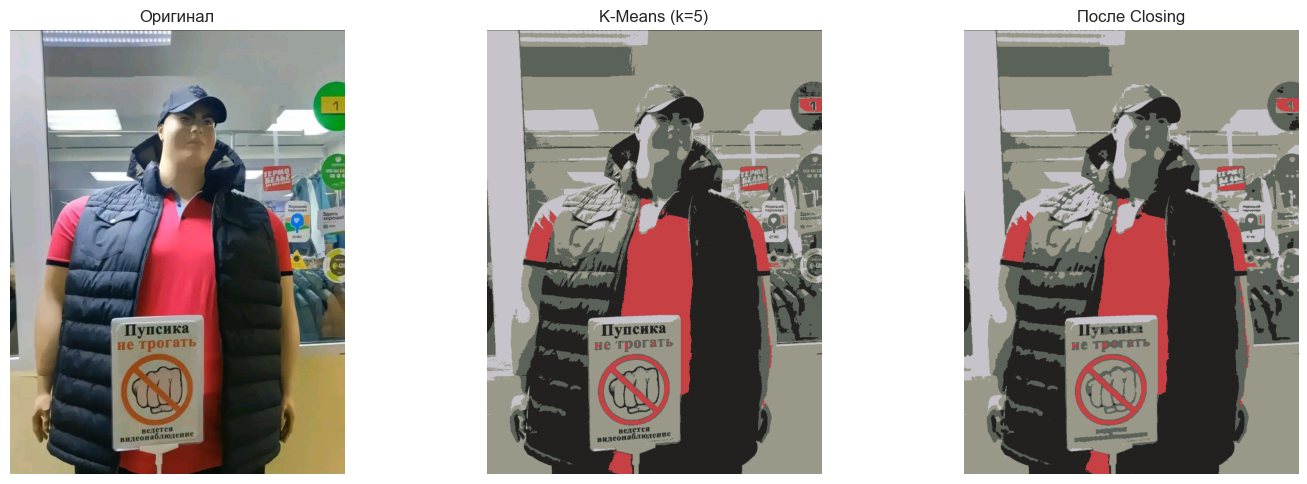

In [3]:
def task1_kmeans_segmentation(image_path: str, k: int = 5):
    if not os.path.exists(image_path):
        img = np.random.randint(0, 255, (300, 300, 3), dtype=np.uint8)
    else:
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # [H, W, C]
    
    H, W, C = img.shape
    
    pixel_values = img.reshape((-1, 3)).astype(np.float32) # [H*W, 3]
    
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        data=pixel_values, 
        K=k, 
        bestLabels=None, 
        criteria=criteria, 
        attempts=10, 
        flags=cv2.KMEANS_RANDOM_CENTERS
    )
    
    centers = np.uint8(centers) # [K, 3]
    
    segmented_flattened = centers[labels.flatten()] # [H*W, 3]
    segmented_img = segmented_flattened.reshape((H, W, 3)) # [H, W, 3]
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed_img = np.zeros_like(segmented_img)
    
    for i in range(k):
        mask = (labels.flatten() == i).reshape(H, W).astype(np.uint8) * 255
        closed_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        
        closed_img[closed_mask == 255] = centers[i]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img); axes[0].set_title('Оригинал')
    axes[1].imshow(segmented_img); axes[1].set_title(f'K-Means (k={k})')
    axes[2].imshow(closed_img); axes[2].set_title('После Closing')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

task1_kmeans_segmentation('data/pupsik.jpg', k=5)

# 2. Реализовать алгоритм локальной бинаризации вручную: для каждого пикселя вычислять среднее значение яркости в окне 15×15 вокруг него и сравнивать с порогом (например, порог = среднее − C). Не использовать cv2.adaptiveThreshold. Сравнить результат с cv2.adaptiveThreshold (ADAPTIVE_MEAN).

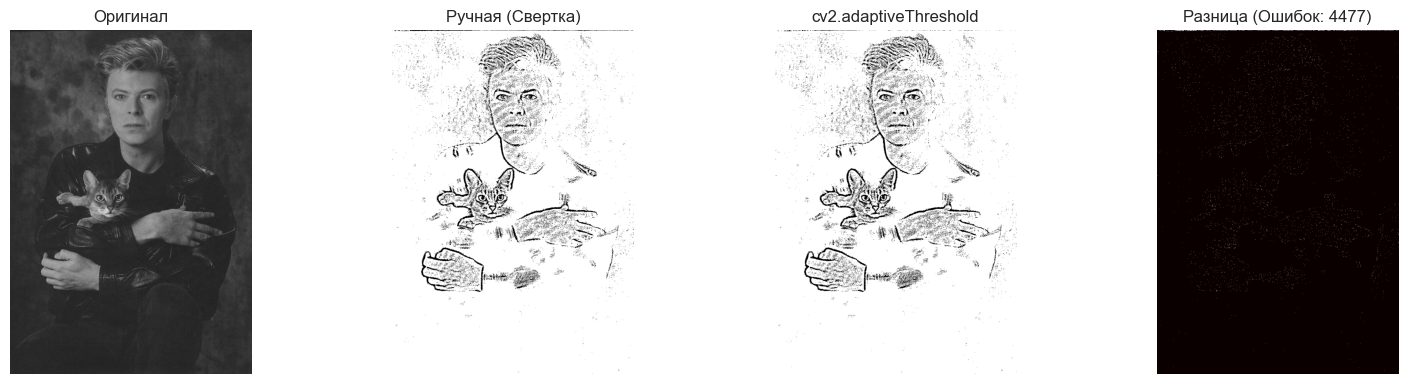

In [4]:
def task2_local_binarization(image_path: str, block_size: int = 15, C: int = 10):
    if not os.path.exists(image_path):
        img = np.random.randint(0, 255, (200, 200), dtype=np.uint8)
    else:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # [H, W]
    
    kernel = np.ones((block_size, block_size), dtype=np.float32) / (block_size ** 2)
    local_mean = cv2.filter2D(img.astype(np.float32), -1, kernel) #[H, W]
    
    threshold = local_mean - C
    manual_binary = np.where(img > threshold, 255, 0).astype(np.uint8)
    
    cv2_binary = cv2.adaptiveThreshold(
        img, 
        maxValue=255, 
        adaptiveMethod=cv2.ADAPTIVE_THRESH_MEAN_C, 
        thresholdType=cv2.THRESH_BINARY, 
        blockSize=block_size, 
        C=C
    )
    
    # Сравнение
    diff = cv2.absdiff(manual_binary, cv2_binary)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Оригинал')
    axes[1].imshow(manual_binary, cmap='gray'); axes[1].set_title('Ручная (Свертка)')
    axes[2].imshow(cv2_binary, cmap='gray'); axes[2].set_title('cv2.adaptiveThreshold')
    axes[3].imshow(diff, cmap='hot'); axes[3].set_title(f'Разница (Ошибок: {np.count_nonzero(diff)})')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

task2_local_binarization('data/pic.jpg')

# 3. Применить морфологические операции эрозии и расширения (cv2.erode и cv2.dilate) к бинарному изображению. Показать, как последовательность операций (открытие и закрытие) влияет на форму объектов и шум.

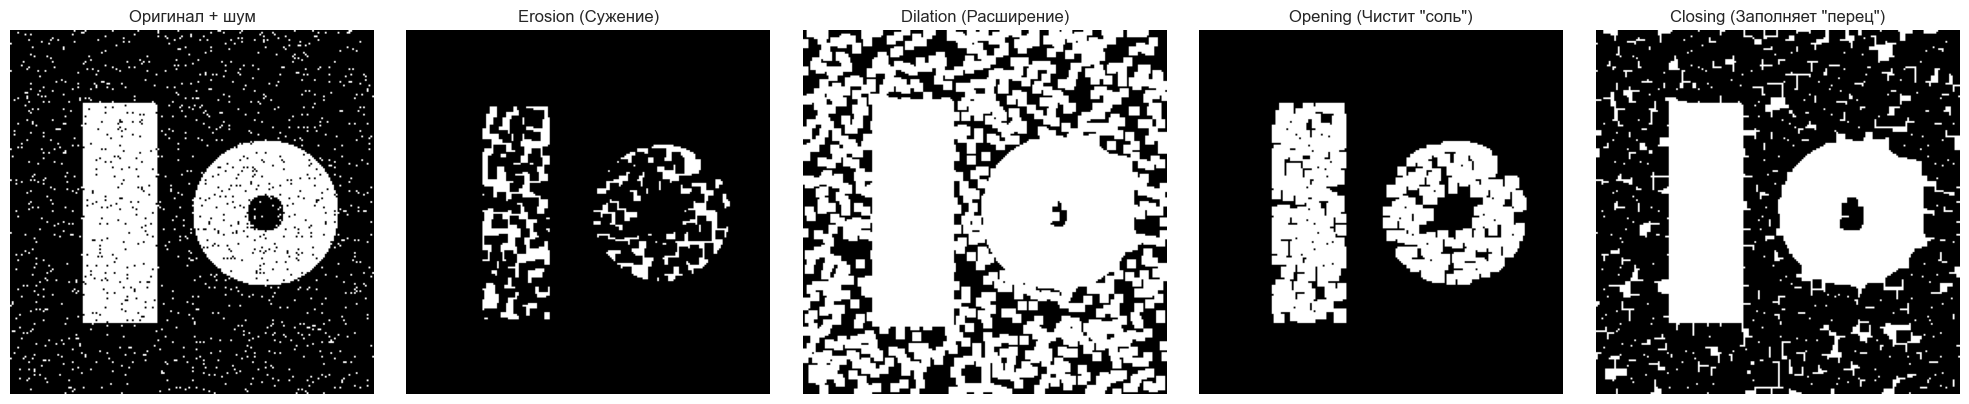

In [5]:
def task3_morphology():
    img = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(img, (40, 40), (80, 160), 255, -1)
    cv2.circle(img, (140, 100), 40, 255, -1)
    
    cv2.circle(img, (140, 100), 10, 0, -1)
    
    noise = np.random.randint(0, 255, (200, 200))
    img[noise > 245] = 255
    img[(noise < 10) & (img == 255)] = 0
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    
    erode = cv2.erode(img, kernel, iterations=1)
    dilate = cv2.dilate(img, kernel, iterations=1)
    opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    
    titles =['Оригинал + шум', 'Erosion (Сужение)', 'Dilation (Расширение)', 'Opening (Чистит "соль")', 'Closing (Заполняет "перец")']
    images =[img, erode, dilate, opening, closing]
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i in range(5):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

task3_morphology()

# 4. Реализовать морфологическое расширение вручную: для каждого пикселя устанавливать единицу, если хотя бы один сосед из структурирующего элемента 3×3 равен единице. Сравнить результат с cv2.dilate.

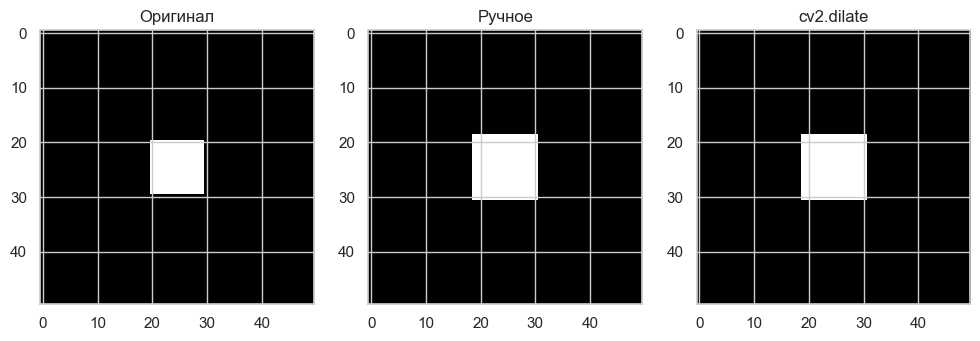

In [6]:
def task4_manual_dilation():
    img = np.zeros((50, 50), dtype=np.uint8)
    img[20:30, 20:30] = 1 # Квадрат в центре
    
    kernel_size = 3
    pad = kernel_size // 2
    
    padded_img = np.pad(img, pad_width=pad, mode='constant', constant_values=0)
    
    windows = sliding_window_view(padded_img, window_shape=(kernel_size, kernel_size))
    
    manual_dilated = windows.max(axis=(2, 3))
    
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    cv2_dilated = cv2.dilate(img, kernel, iterations=1)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Оригинал')
    axes[1].imshow(manual_dilated, cmap='gray'); axes[1].set_title('Ручное')
    axes[2].imshow(cv2_dilated, cmap='gray'); axes[2].set_title('cv2.dilate')
    plt.show()

task4_manual_dilation()

# 5. Применить медианный, гауссов и билинейный фильтр к изображению с шумом. Используя cv2.medianBlur, cv2.GaussianBlur и cv2.blur, сравнить устранение импульсного и гауссовского шума.

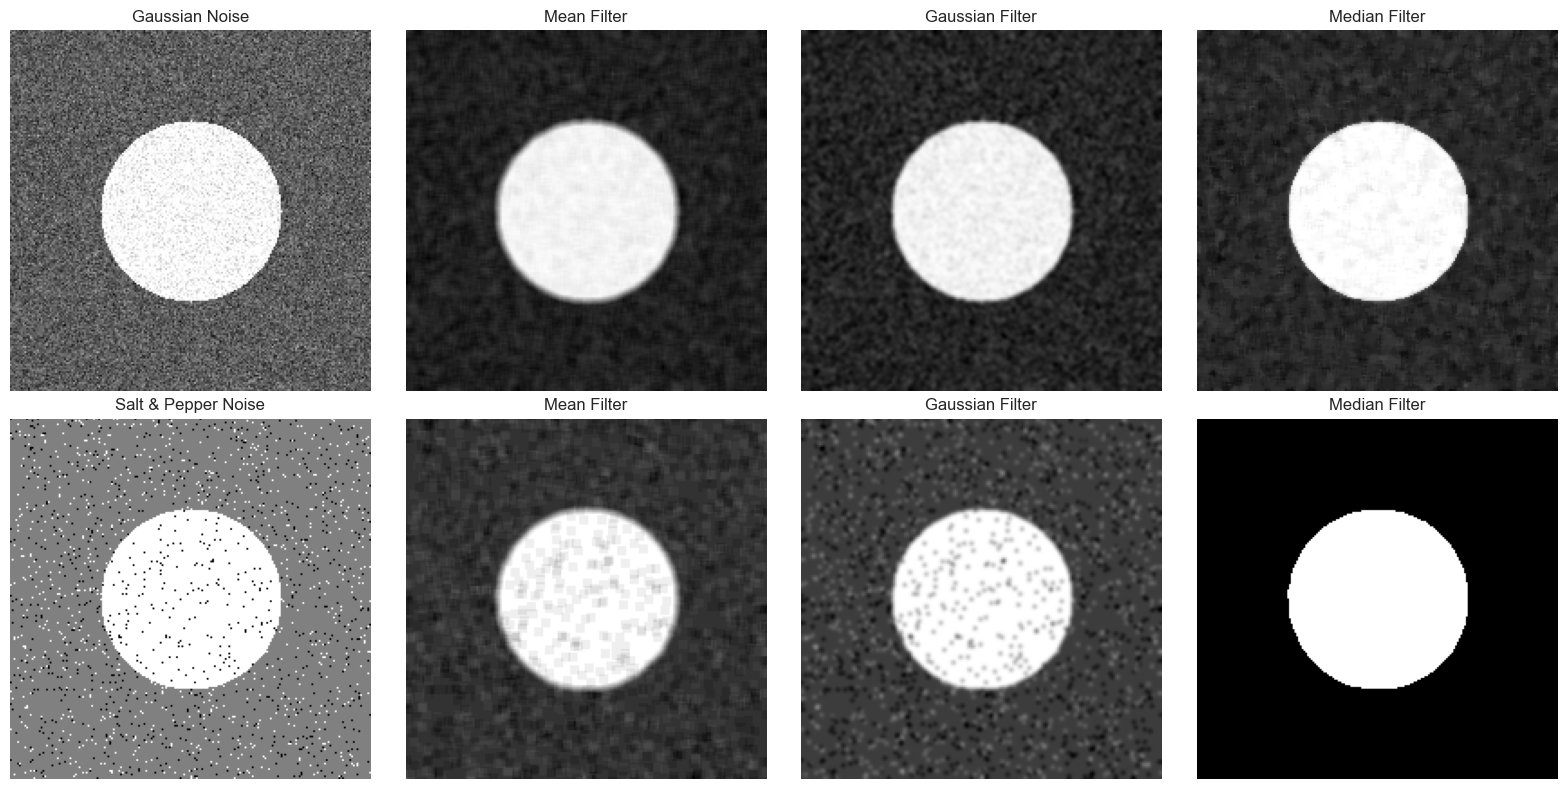

In [7]:
def task5_noise_filtering():
    base = np.ones((200, 200), dtype=np.uint8) * 128
    cv2.circle(base, (100, 100), 50, 255, -1)
    
    gauss_noise = np.random.normal(0, 20, base.shape).astype(np.float32)
    img_gauss = np.clip(base + gauss_noise, 0, 255).astype(np.uint8)
    
    img_sp = base.copy()
    prob = 0.05 
    rnd = np.random.rand(*base.shape)
    img_sp[rnd < prob/2] = 0
    img_sp[rnd > 1 - prob/2] = 255
    
    k = 5
    g_blur = cv2.blur(img_gauss, (k, k))
    g_gauss = cv2.GaussianBlur(img_gauss, (k, k), 0)
    g_median = cv2.medianBlur(img_gauss, k)
    
    sp_blur = cv2.blur(img_sp, (k, k))
    sp_gauss = cv2.GaussianBlur(img_sp, (k, k), 0)
    sp_median = cv2.medianBlur(img_sp, k)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    axes[0, 0].imshow(img_gauss, cmap='gray'); axes[0, 0].set_title('Gaussian Noise')
    axes[0, 1].imshow(g_blur, cmap='gray'); axes[0, 1].set_title('Mean Filter')
    axes[0, 2].imshow(g_gauss, cmap='gray'); axes[0, 2].set_title('Gaussian Filter')
    axes[0, 3].imshow(g_median, cmap='gray'); axes[0, 3].set_title('Median Filter')
    
    axes[1, 0].imshow(img_sp, cmap='gray'); axes[1, 0].set_title('Salt & Pepper Noise')
    axes[1, 1].imshow(sp_blur, cmap='gray'); axes[1, 1].set_title('Mean Filter')
    axes[1, 2].imshow(sp_gauss, cmap='gray'); axes[1, 2].set_title('Gaussian Filter')
    axes[1, 3].imshow(sp_median, cmap='gray'); axes[1, 3].set_title('Median Filter')
    
    for ax in axes.flatten(): ax.axis('off')
    plt.tight_layout()
    plt.show()

task5_noise_filtering()

# 6. Реализовать оператор Собеля вручную: создать маски Sx и Sy, выполнить свёртку numpy и построить карту градиентной величины. Сравнить результат с cv2.Sobel.

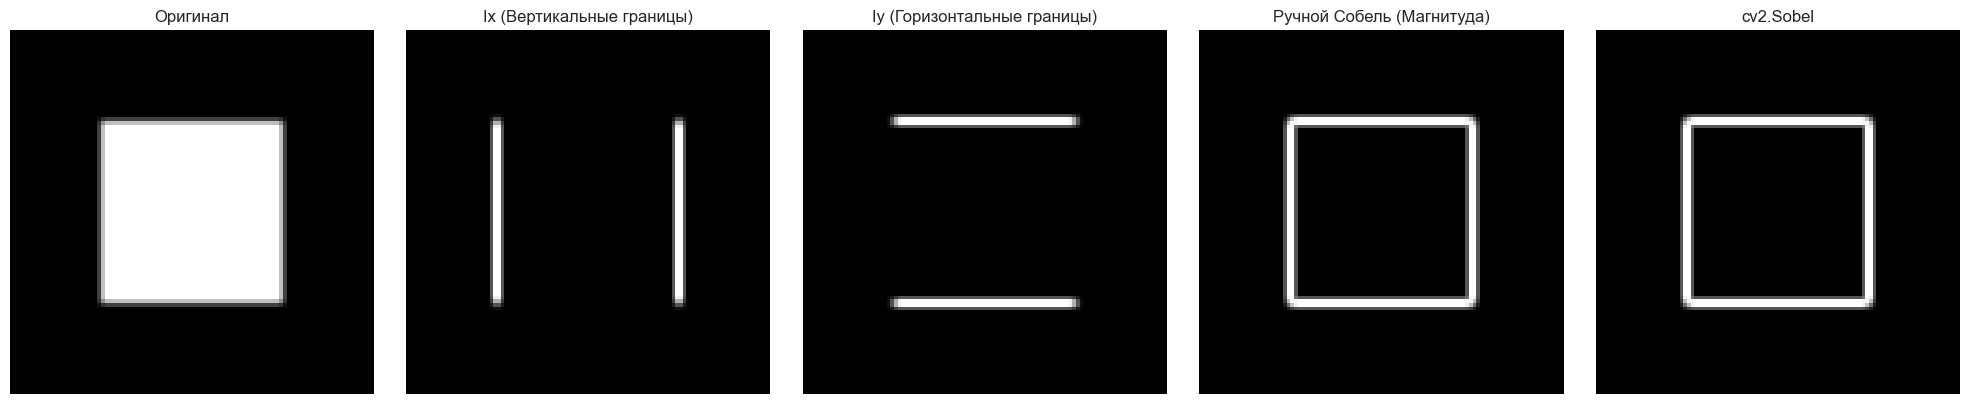

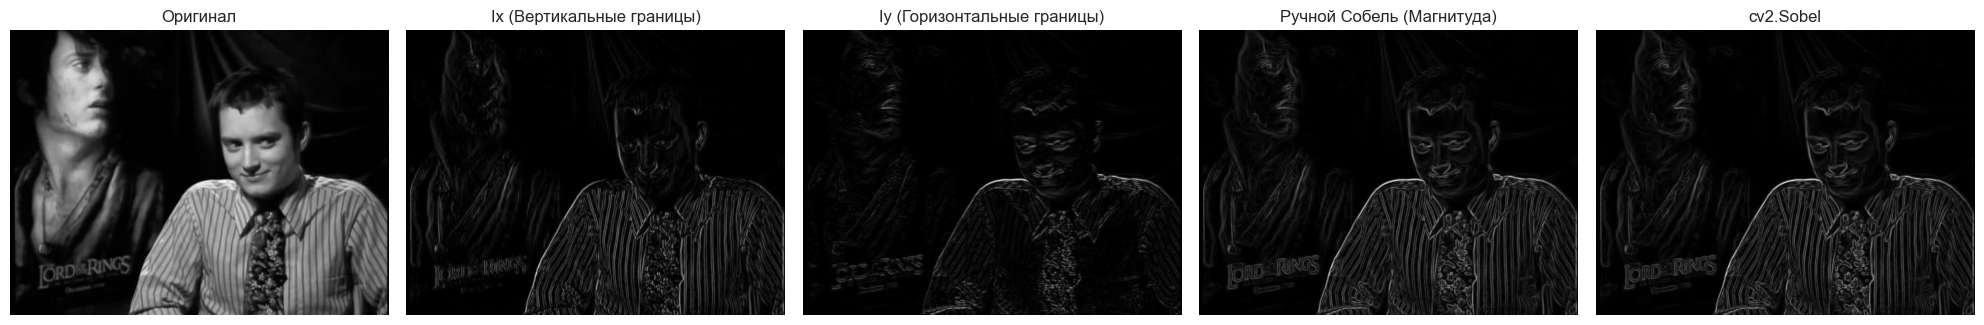

In [ ]:
def task6_manual_sobel(image_path=None):
    if not image_path:
            img = np.zeros((100, 100), dtype=np.uint8)
            img[25:75, 25:75] = 255
            img = cv2.GaussianBlur(img, (3, 3), 0) # Слегка размоем края
    else:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # [H, W]

    
    # 1. Маски Собеля
    Sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)
                   
    Sy = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float32)
                   
    Ix = convolve2d(img.astype(np.float32), Sx, mode='same', boundary='symm')
    Iy = convolve2d(img.astype(np.float32), Sy, mode='same', boundary='symm')
    
    G_manual = np.sqrt(Ix**2 + Iy**2)
    G_manual = np.clip((G_manual / G_manual.max()) * 255, 0, 255).astype(np.uint8)
    
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    G_cv2 = np.sqrt(sobelx**2 + sobely**2)
    G_cv2 = np.clip((G_cv2 / G_cv2.max()) * 255, 0, 255).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title('Оригинал')
    axes[1].imshow(np.abs(Ix), cmap='gray'); axes[1].set_title('Ix (Вертикальные границы)')
    axes[2].imshow(np.abs(Iy), cmap='gray'); axes[2].set_title('Iy (Горизонтальные границы)')

    axes[3].imshow(G_manual, cmap='gray'); axes[3].set_title('Ручной Собель (Магнитуда)')
    axes[4].imshow(G_cv2, cmap='gray'); axes[4].set_title('cv2.Sobel')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
task6_manual_sobel()
task6_manual_sobel('data/weegsjpg.jpg')

# 7. На датасете MNIST обучить классификаторы SVM и DecisionTreeClassifier. Построить графики «точность vs глубина дерева» и «точность vs параметр C для SVM».

Обучение Decision Trees...


100%|██████████| 6/6 [00:04<00:00,  1.47it/s]


Обучение SVM...


100%|██████████| 4/4 [00:52<00:00, 13.13s/it]


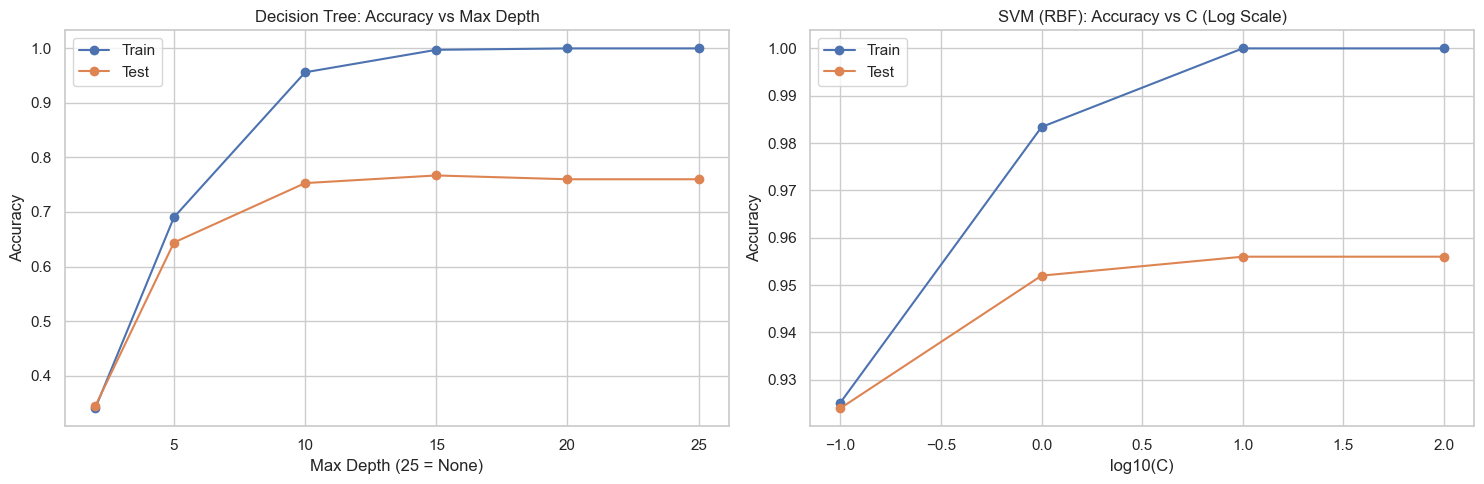

In [9]:
from tqdm import tqdm

def task7_ml_classifiers():
    X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
    
    X = X / 255.0
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=5000, test_size=1000, random_state=42, stratify=y)
    
    depths =[2, 5, 10, 15, 20, None]
    dt_train_acc, dt_test_acc = [],[]
    
    print("Обучение Decision Trees...")
    for d in tqdm(depths):
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(X_train, y_train)
        dt_train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
        dt_test_acc.append(accuracy_score(y_test, dt.predict(X_test)))
        
    C_values =[0.1, 1.0, 10.0, 100.0]
    svm_train_acc, svm_test_acc = [],[]
    
    print("Обучение SVM...")
    for c in tqdm(C_values):
        svm = SVC(C=c, kernel='rbf', random_state=42)
        svm.fit(X_train, y_train)
        svm_train_acc.append(accuracy_score(y_train, svm.predict(X_train)))
        svm_test_acc.append(accuracy_score(y_test, svm.predict(X_test)))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    plot_depths =[25 if d is None else d for d in depths]
    
    axes[0].plot(plot_depths, dt_train_acc, marker='o', label='Train')
    axes[0].plot(plot_depths, dt_test_acc, marker='o', label='Test')
    axes[0].set_title('Decision Tree: Accuracy vs Max Depth')
    axes[0].set_xlabel('Max Depth (25 = None)')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    
    axes[1].plot(np.log10(C_values), svm_train_acc, marker='o', label='Train')
    axes[1].plot(np.log10(C_values), svm_test_acc, marker='o', label='Test')
    axes[1].set_title('SVM (RBF): Accuracy vs C (Log Scale)')
    axes[1].set_xlabel('log10(C)')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

task7_ml_classifiers()

# 8. Реализовать функцию hinge loss вручную для бинарной классификации. Также реализовать градиент этой функции для дальнейшего обучения. Проверить корректность на небольшом наборе данных.

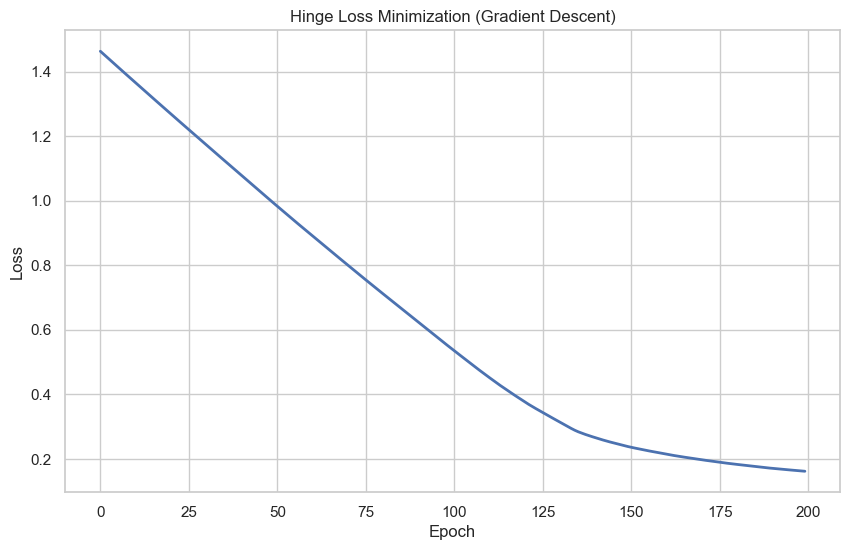

Final Loss: 0.1615
Optimized Weights: [ 0.23344891 -0.37131396  0.96573907]


In [10]:
def task8_hinge_loss():
    X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
    y = np.where(y == 0, -1, 1)
    
    X_padded = np.c_[np.ones((X.shape[0], 1)), X]
    
    w = np.random.randn(3)
    
    def hinge_loss(w, X, y):
        margins = y * np.dot(X, w)
        loss = np.maximum(0, 1 - margins)
        return np.mean(loss)

    def hinge_gradient(w, X, y):
        margins = y * np.dot(X, w)
        mask = (margins < 1).astype(float)
        grad = - (mask * y)[:, np.newaxis] * X
        return np.mean(grad, axis=0)
    
    lr = 0.01
    losses =[]
    
    for epoch in range(200):
        loss = hinge_loss(w, X_padded, y)
        grad = hinge_gradient(w, X_padded, y)
        w -= lr * grad
        losses.append(loss)
        
    plt.plot(losses, lw=2)
    plt.title('Hinge Loss Minimization (Gradient Descent)')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.show()
    
    print(f"Final Loss: {losses[-1]:.4f}")
    print(f"Optimized Weights: {w}")

task8_hinge_loss()

# 9. Построить две версии CNN на PyTorch или TensorFlow: одну с dropout, вторую без. Обучить на MNIST и сравнить точности и скорость сходимости.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



--- Обучение модели (Dropout: False) ---


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1   │ Conv2d    │    320 │ train │     0 │
│ 1 │ conv2   │ Conv2d    │ 18.5 K │ train │     0 │
│ 2 │ pool    │ MaxPool2d │      0 │ train │     0 │
│ 3 │ fc1     │ Linear    │  401 K │ train │     0 │
│ 4 │ fc2     │ Linear    │  1.3 K │ train │     0 │
│ 5 │ dropout │ Dropout   │      0 │ train │     0 │
└───┴─────────┴───────────┴────────┴───────┴───────┘

Trainable params: 421 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 421 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=5` reached.


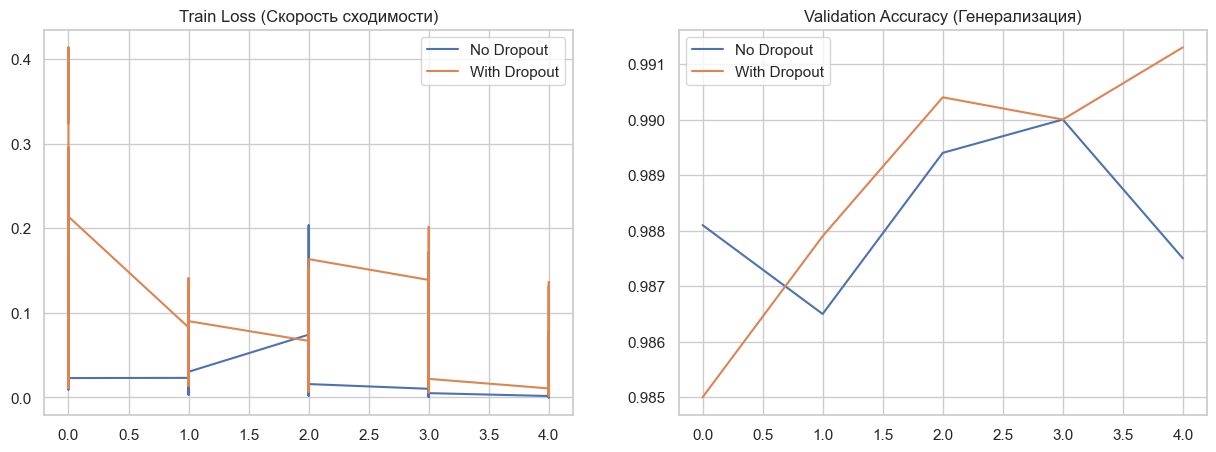

In [ ]:
class LitMNIST(pl.LightningModule):
    def __init__(self, use_dropout: bool = False):
        super().__init__()
        self.use_dropout = use_dropout
        self.save_hyperparameters()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        #[B, 1, 28, 28] -> [B, 32, 14, 14]
        x = self.pool(F.relu(self.conv1(x)))
        #[B, 32, 14, 14] ->[B, 64, 7, 7]
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten [B, 64*7*7]
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)
            
        x = self.fc2(x) # Логиты[B, 10]
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = accuracy_score(y.cpu(), preds.cpu())
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

def task9_train_dropout_comparison():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    
    full_train = datasets.MNIST('data', train=True, download=True, transform=transform)
    val_data = datasets.MNIST('data', train=False, transform=transform)
    
    
    train_loader = DataLoader(full_train, batch_size=64, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_data, batch_size=1000, shuffle=False)
    
    results = {}
    
    for use_drop in [False, True]:
        print(f"\n--- Обучение модели (Dropout: {use_drop}) ---")
        model = LitMNIST(use_dropout=use_drop)
        
        logger = CSVLogger("logs", name=f"mnist_dropout_{use_drop}")
        
        trainer = Trainer(
            max_epochs=5, 
            logger=logger,
            enable_progress_bar=True, 
            accelerator='auto'
        )
        
        trainer.fit(model, train_loader, val_loader)
        
        metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
        results[use_drop] = metrics
        
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for use_drop, df in results.items():
        label = 'With Dropout' if use_drop else 'No Dropout'
        # Фильтруем nan (разные логи пишутся на разных шагах)
        val_df = df.dropna(subset=['val_acc'])
        train_df = df.dropna(subset=['train_loss'])
        
        axes[0].plot(train_df['epoch'], train_df['train_loss'], label=label)
        axes[1].plot(val_df['epoch'], val_df['val_acc'], label=label)
        
    axes[0].set_title('Train Loss (Скорость сходимости)')
    axes[0].legend()
    axes[1].set_title('Validation Accuracy (Генерализация)')
    axes[1].legend()
    plt.show()

task9_train_dropout_comparison()

# 10. Использовать афинные преобразования (RandomRotation, RandomTranslation, RandomScale) при обучении CNN на CIFAR‑10. Сравнить модель, обученную с аугментациями и без них, и сделать выводы.

Подготовка данных CIFAR-10...


c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Обучение модели: No_Augmentations



┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential │ 93.2 K │ train │     0 │
│ 1 │ classifier │ Sequential │  527 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 620 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 620 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


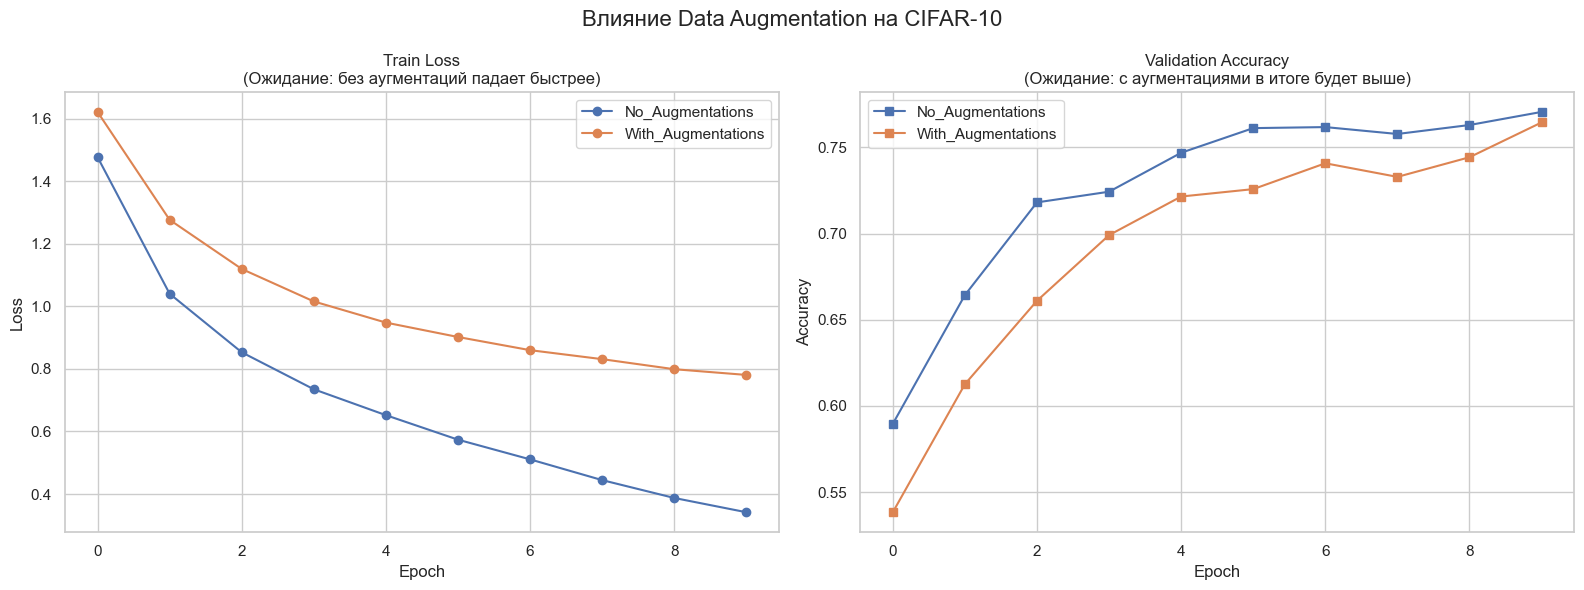

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

class LitCIFAR(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.save_hyperparameters()
        
        # Вход: [Batch, 3, 32, 32]
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),  # ->[B, 32, 16, 16]
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # ->[B, 64, 8, 8]
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2) # -> [B, 128, 4, 4]
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10) # 10 классов CIFAR
        )

    def forward(self, x):
        # x: [Batch, 3, 32, 32]
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten:[Batch, 128*4*4]
        return self.classifier(x) # Logits:[Batch, 10]

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        
        acc = (preds == y).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        # Используем AdamW (Adam с правильным Weight Decay) для лучшей регуляризации
        return torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-4)


def task10_augmentations():
    base_transform = v2.Compose([
        v2.ToImage(), # Замена старому ToTensor()
        v2.ToDtype(torch.float32, scale=True), # Нормализует 0..255 -> 0..1
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    aug_transform = v2.Compose([
        v2.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    full_train_base = datasets.CIFAR10(root='./data', train=True, download=True, transform=base_transform)
    full_train_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=aug_transform)
    val_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=base_transform)
    
    
    batch_size = 128
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
    
    configs = {
        "No_Augmentations": DataLoader(full_train_base, batch_size=batch_size, shuffle=True, num_workers=0),
        "With_Augmentations": DataLoader(full_train_aug, batch_size=batch_size, shuffle=True, num_workers=0)
    }
    
    results = {}
    epochs = 10
    
    for name, train_loader in configs.items():
        print(f"\nОбучение модели: {name}\n")
        
        model = LitCIFAR()
        logger = CSVLogger("logs", name=f"cifar_{name}")
        
        trainer = Trainer(
            max_epochs=epochs,
            logger=logger,
            accelerator='auto', 
            devices=1,
            enable_progress_bar=True,
            log_every_n_steps=10
        )
        
        trainer.fit(model, train_loader, val_loader)
        
        metrics_path = f"{logger.log_dir}/metrics.csv"
        df = pd.read_csv(metrics_path)
        results[name] = df

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for name, df in results.items():
        epoch_metrics = df.groupby('epoch').mean().reset_index()
        
        if 'train_loss' in epoch_metrics.columns:
            axes[0].plot(epoch_metrics['epoch'], epoch_metrics['train_loss'], marker='o', label=name)
        if 'val_acc' in epoch_metrics.columns:
            axes[1].plot(epoch_metrics['epoch'], epoch_metrics['val_acc'], marker='s', label=name)
            
    axes[0].set_title('Train Loss\n(Ожидание: без аугментаций падает быстрее)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_title('Validation Accuracy\n(Ожидание: с аугментациями в итоге будет выше)')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle("Влияние Data Augmentation на CIFAR-10", fontsize=16)
    plt.tight_layout()
    plt.show()

task10_augmentations()